# Trusting Code — LLM Coding & Verification

For the rest of SWDB you will repeatedly find yourself verifying code written by colleagues, found online, or generated by LLMs. In this workshop we'll practice that role on an LLM-generated analysis.

The analysis code lives in `code/workshops/src/`. It was run ahead of time and saved intermediate artifacts (parquet / JSON) under `/scratch`. The figures below are generated from these artifacts (the full re-run takes a looooong time). Skim through the first set of figures to get a sense of how the analysis worked, then consider the verification questions and answer them (and any other questions that come to mind!) to convince yourself that this analysis is sound.

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;">

#### Objective

_This is a small portion of the full prompt used to generate this analysis:_

We are generating an analysis of tuning to drifting gratings (and natural stimuli) in optical physiology data (2-photon imaging of the GCaMP6s calcium indicator) from the Allen Institute V1 DeepDive data set, to be combined with inferred cell types and connectivity from the EM portion of the data set.

One of the first things the LLM did was identify responsive neurons, here it identified the "most" responsive neuron:

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make the analysis package importable regardless of launch directory
for cand in [os.getcwd(), os.path.join(os.getcwd(), 'code', 'workshops'),
             os.path.dirname(os.getcwd()), '/root/capsule/code/workshops']:
    if os.path.isdir(os.path.join(cand, 'src')):
        sys.path.insert(0, cand)
        break

from src import artifacts, metrics, tuning_curves as tc

S1, S2 = artifacts.STEP1_DIR, artifacts.STEP2_DIR
meta = artifacts.load_json(S1 / 'selected_roi.json')
ROI, PLANE = meta['roi_id'], meta['plane']
print(f"Selected ROI {ROI} ({PLANE}), SNR={meta['snr']:.2f}")

Selected ROI 16 (plane-3), SNR=7.96


## 1 — Orientation tuning curve for one ROI

This first figure displays the final output of our analysis. This is the orientation tuning curve of the single most grating-responsive ROI, with a von Mises tuning function fit overlaid.

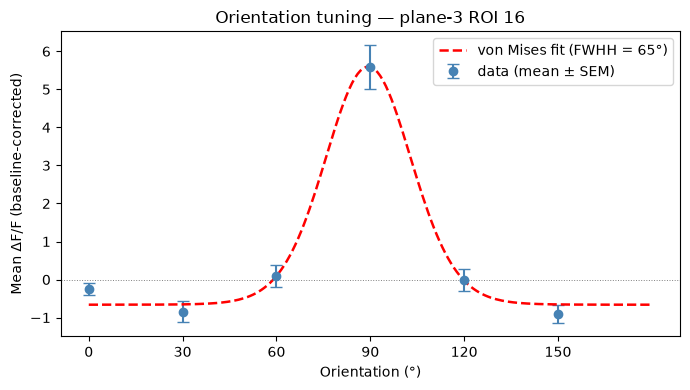

In [2]:
ori = artifacts.load_table(S1 / 'ori_tuning.parquet')
popt = meta['fit_ori']['popt']
xf = np.linspace(0, 180, 200)
yf = metrics.orientation_von_mises(xf, *popt)

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(ori['orientation'], ori['mean_response'], yerr=ori['sem'],
            fmt='o', color='steelblue', capsize=4, ms=6, label='data (mean ± SEM)')
ax.plot(xf, yf, 'r--', lw=1.8, label=f"von Mises fit (FWHH = {meta['fit_ori']['fwhh']:.0f}°)")
ax.axhline(0, color='gray', ls=':', lw=0.7)
ax.set_xticks(ori['orientation'])
ax.set_xlabel('Orientation (°)')
ax.set_ylabel('Mean ΔF/F (baseline-corrected)')
ax.set_title(f'Orientation tuning — {PLANE} ROI {ROI}')
ax.legend()
plt.tight_layout(); plt.show()

## 2 — Exploring the response in grating space and time

To understand how this tuning function was built, the following figures should help orient you to how the data is organized. First this is the whole-session ΔF/F trace of this ROI with each stimulus epoch shaded, to show when drifting gratings were shown relative to other stimuli.

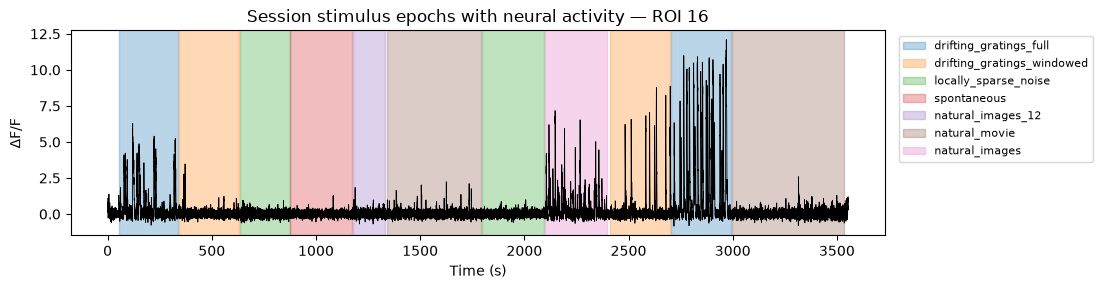

In [3]:
trace = artifacts.load_table(S1 / 'roi_trace.parquet')
epochs = artifacts.load_table(S1 / 'epochs.parquet')
dg = artifacts.load_table(S1 / 'stim_dg.parquet')
ts, dff = trace['time'].values, trace['dff'].values

names = list(epochs['stim_name'].unique())
ep_colors = dict(zip(names, plt.cm.tab10.colors))

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(ts, dff, color='black', lw=0.6)
for name in names:
    sub = epochs[epochs['stim_name'] == name]
    for i, (a, b) in enumerate(zip(sub['start_time'], sub['stop_time'])):
        ax.axvspan(a, b, color=ep_colors[name], alpha=0.3, label=name if i == 0 else None)
ax.set_xlabel('Time (s)'); ax.set_ylabel(r'$\Delta$F/F')
ax.set_title(f'Session stimulus epochs with neural activity — ROI {ROI}')
ax.legend(bbox_to_anchor=(1.01, 1.0), loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

Zooming into the drifting-gratings block, we can shade each trial by its grating orientation. The lower panel zooms to a ~25 s chunk so that individual trial responses are visible.

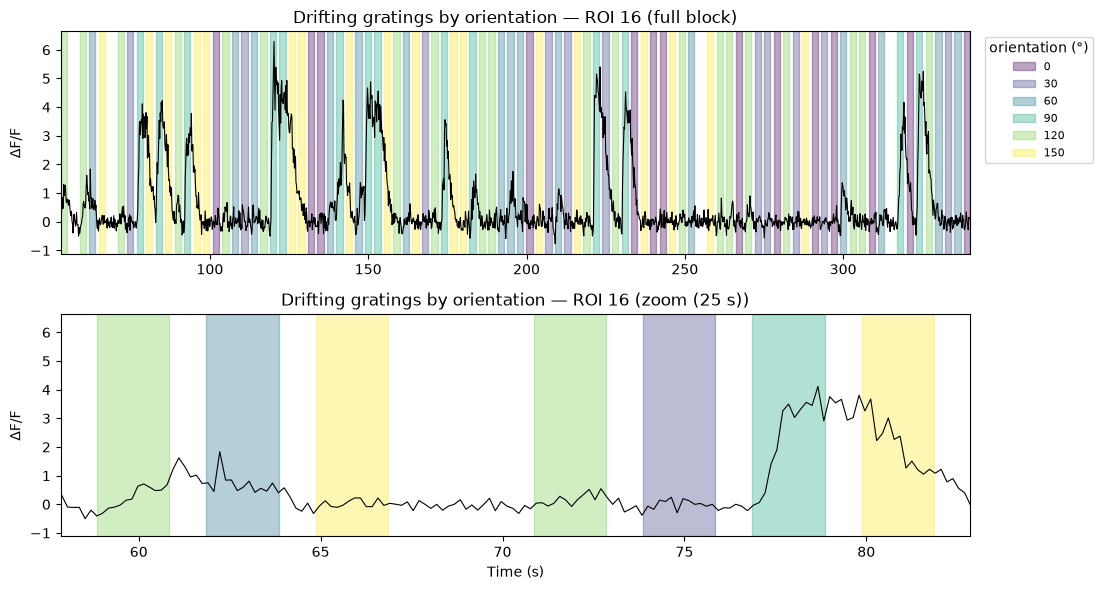

In [4]:
dgep = epochs[epochs['stim_name'] == 'drifting_gratings_full'].iloc[0]
pres = dg[dg['start_time'] <= dgep['stop_time']]
oris = sorted(pres['orientation'].unique())
o_colors = dict(zip(oris, plt.colormaps['viridis'].resampled(len(oris)).colors))

def shade_orientation(ax):
    for o in oris:
        sub = pres[pres['orientation'] == o]
        for i, (a, b) in enumerate(zip(sub['start_time'], sub['stop_time'])):
            ax.axvspan(a, b, color=o_colors[o], alpha=0.35, label=int(o) if i == 0 else None)

blk = (ts > dgep['start_time']) & (ts < dgep['stop_time'])
z0 = dgep['start_time'] + 5.0
fig, axes = plt.subplots(2, 1, figsize=(11, 6))
for ax, xlim, title in [(axes[0], (dgep['start_time'], dgep['stop_time']), 'full block'),
                        (axes[1], (z0, z0 + 25), 'zoom (25 s)')]:
    ax.plot(ts[blk], dff[blk], color='black', lw=0.8)
    shade_orientation(ax)
    ax.set_xlim(xlim); ax.set_ylabel(r'$\Delta$F/F')
    ax.set_title(f'Drifting gratings by orientation — ROI {ROI} ({title})')
axes[1].set_xlabel('Time (s)')
axes[0].legend(title='orientation (°)', bbox_to_anchor=(1.01, 1.0), loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

The orientation tuning curve is built by averaging responses across trials. This next figure demonstrate the average response across stimuli and shows how the response window was selected.

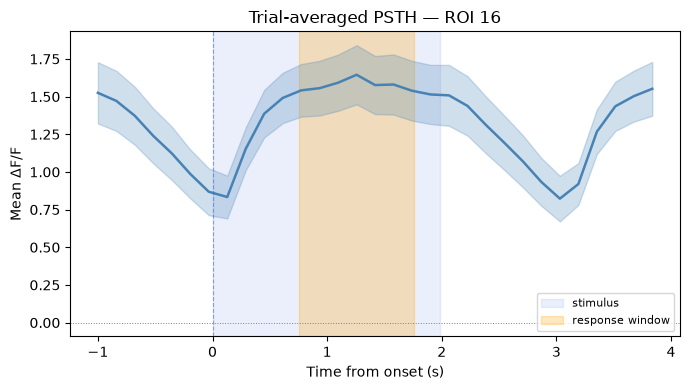

In [5]:
psth = artifacts.load_table(S1 / 'psth.parquet')
fig, ax = plt.subplots(figsize=(7, 4))
ax.axvspan(0, meta['stim_dur'], alpha=0.10, color='royalblue', label='stimulus')
ax.axvspan(meta['resp_start'], meta['resp_end'], alpha=0.25, color='orange', label='response window')
ax.fill_between(psth['t'], psth['mean'] - psth['sem'], psth['mean'] + psth['sem'],
                color='steelblue', alpha=0.25)
ax.plot(psth['t'], psth['mean'], color='steelblue', lw=1.8)
ax.axvline(0, color='royalblue', ls='--', lw=0.8, alpha=0.6)
ax.axhline(0, color='gray', ls=':', lw=0.7)
ax.set_xlabel('Time from onset (s)'); ax.set_ylabel('Mean ΔF/F')
ax.set_title(f'Trial-averaged PSTH — ROI {ROI}')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Verification Questions — single-ROI analysis

**Data & ROI selection**
1. How is the data loaded? What is *zero* time, and what are the time units?
2. How does the code select the most responsive neuron to drifting gratings? Is the selected ROI robustly responsive?

**Response window & baseline**

3. How is the response window chosen, and how is baselining done? What is the timecourse and shape of the response? What do you think of the window's duration and shape?
4. Should the same response window be used across all ROIs (from average behavior) rather than fit per-ROI? What happens if a peak is sought in non-responsive data?

**Conditions & orientation**

5. How are multiple temporal / spatial frequencies handled?
6. Is the conversion of direction to orientation correct? Is the tuning curve reasonable?

**Fitting**

7. Can you verify the fitting of the tuning curve with the von Mises function?

## 3 — Population and metric exploration

Beyond one ROI, the pipeline computed tuning curves for every ROI (`roi_tuning.parquet`) and derived per-ROI metrics: an orientation-selectivity index (OSI), and a variation of this the global orientation selectivity index (gOSI), and von Mises tuning width (`roi_metrics.parquet`).

First, a random sample of orientation tuning curves across the population, to gauge how many ROIs are well-tuned versus noisy.

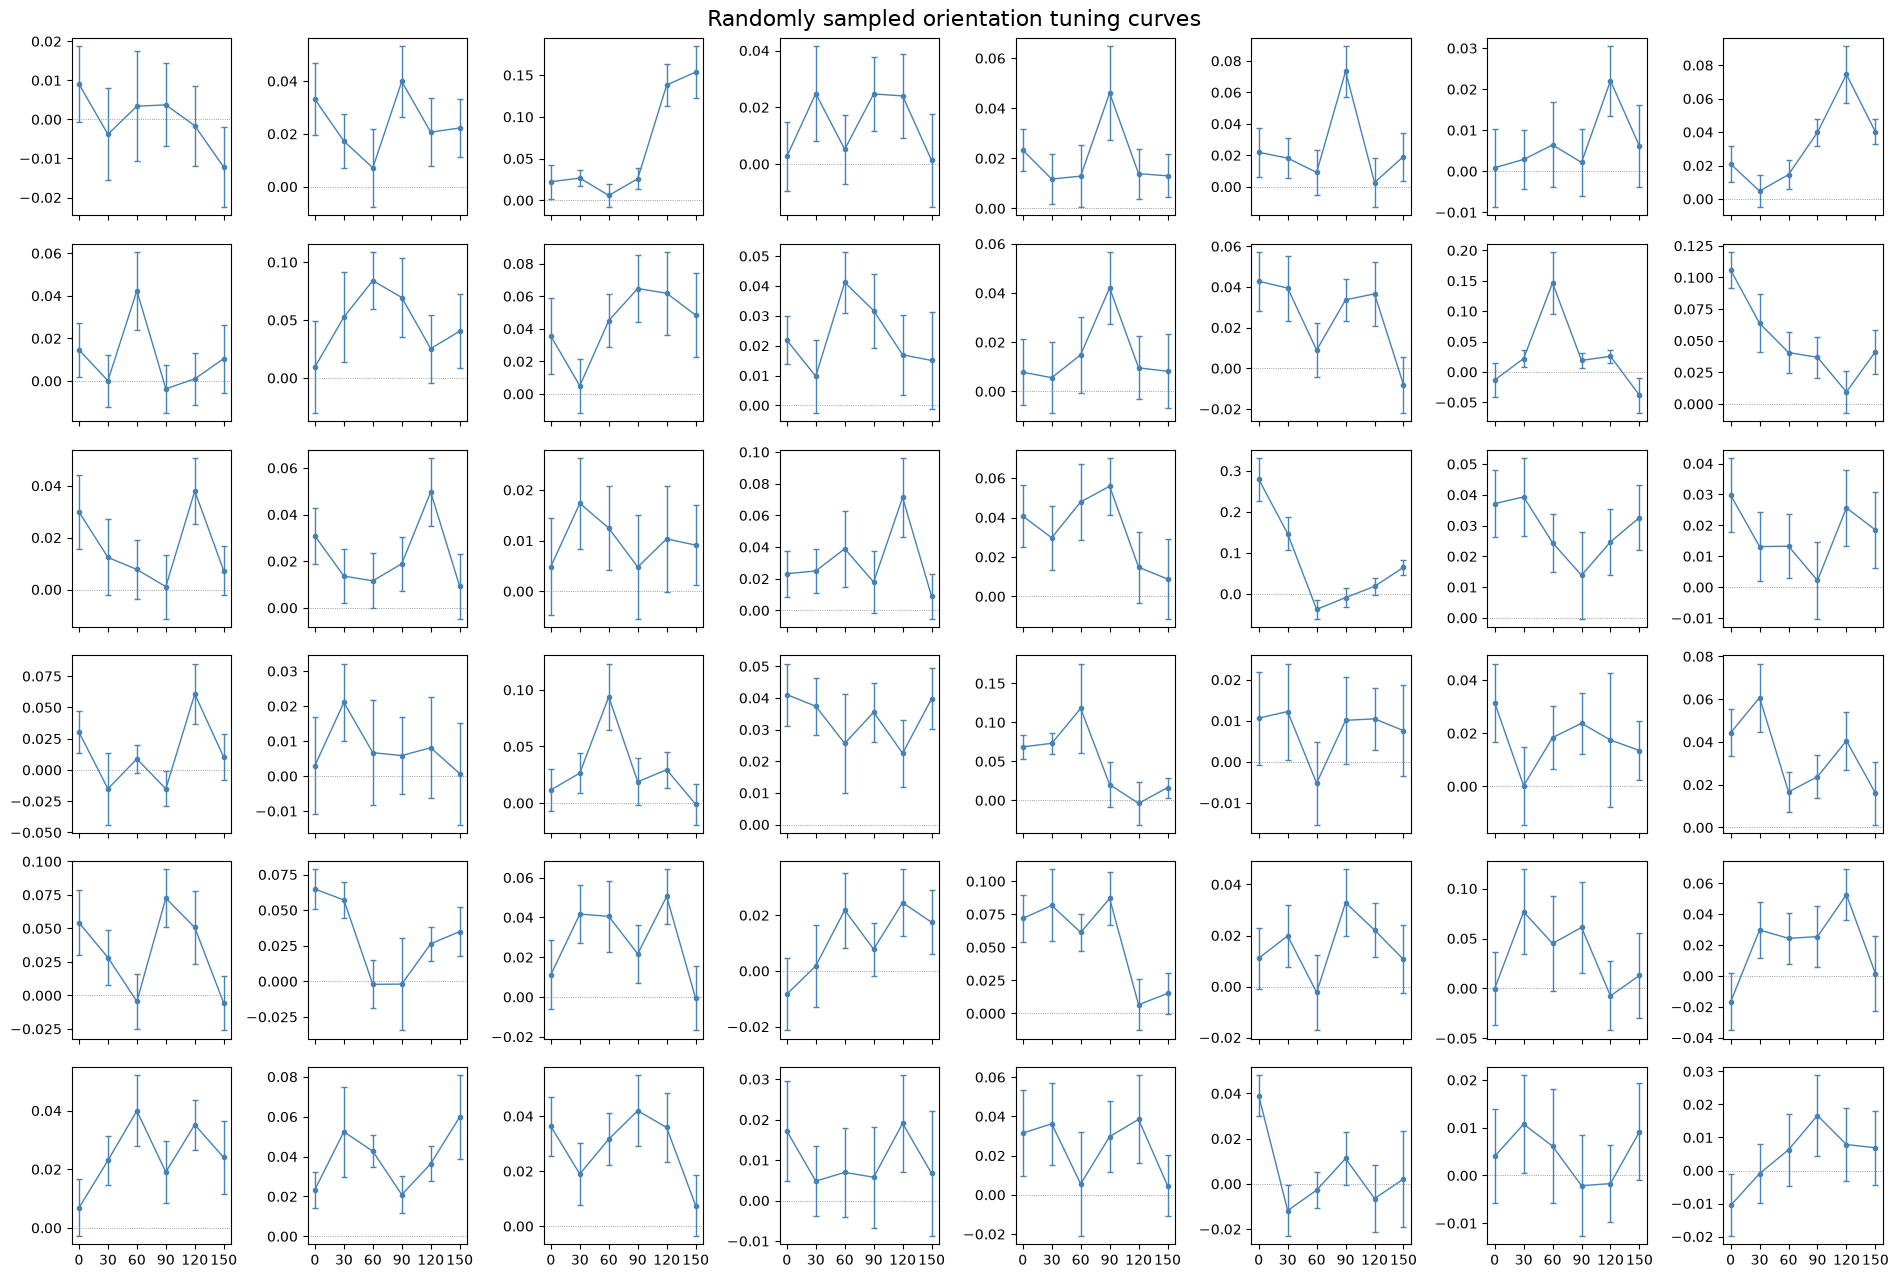

In [6]:
df_tuning = artifacts.load_table(S2 / 'roi_tuning.parquet')
rng = np.random.default_rng(42)
idx = rng.choice(len(df_tuning), size=48, replace=False)

fig, axes = plt.subplots(6, 8, figsize=(19, 13), sharex=True)
for k, ax in zip(idx, axes.flat):
    t = tc.reshape_tuning(df_tuning.iloc[[k]])
    ax.errorbar(t['orientation'], t['mean_response'], yerr=t['sem'],
                fmt='o-', color='steelblue', ms=3, lw=1, capsize=2)
    ax.axhline(0, color='gray', ls=':', lw=0.6)
    ax.set_xticks(t['orientation'])
fig.suptitle('Randomly sampled orientation tuning curves', fontsize=16)
plt.tight_layout(); plt.show()

Next we can look at the relationship between metrics, here tuning width and gOSI, for responsive cells (peak orientation response > 0.2 ΔF/F). We expect sharper tuning (smaller width) to accompany higher selectivity.

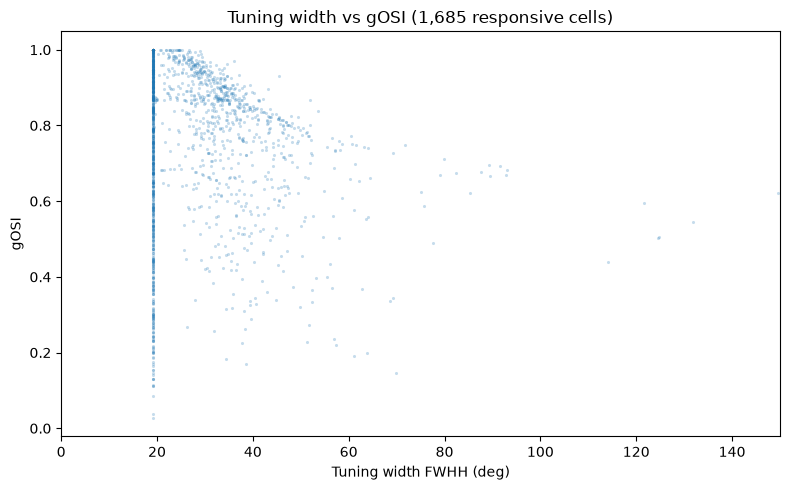

In [7]:
m = artifacts.load_table(S2 / 'roi_metrics.parquet')
mf = m[m[metrics.ORI_MEAN_COLS].max(axis=1) > 0.2]

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(mf['tuning_width'], mf['gOSI'], s=5, alpha=0.25, linewidths=0, rasterized=True)
ax.set_xlim(0, 150)
ax.set_xlabel('Tuning width FWHH (deg)'); ax.set_ylabel('gOSI')
ax.set_title(f'Tuning width vs gOSI ({len(mf):,} responsive cells)')
plt.tight_layout(); plt.show()

## Verification Questions — population & metrics

8. How are missing values handled? How should noisy, essentially non-responsive neurons be handled — and what constitutes "responsive"?
9. Are the OSI / gOSI metrics correctly defined and implemented? Are the values reasonable? How might you constrain them, or what alternatives exist? Do the two metrics agree?
10. Does the relationship between orientation-selectivity index and tuning width make sense?

## 4 — Tuning by EM cell type (exploratory)

Finally, functional metrics are coregistered with EM-inferred cell types (`coregistration_1196.feather`, `soma_and_cell_type_1196.feather`). Per-cell-type orientation tuning curves are peak-normalized and aligned to the preferred orientation (thin = individual cells, thick = mean ± SEM), alongside mean gOSI and tuning width per type.

In [8]:
from src import coreg
cache = S2 / 'roi_cell_type.parquet'
if cache.exists():
    mf_ct = artifacts.load_table(cache)
else:
    try:
        import src.pipeline as pl
        mf_ct = pl.run_step4()
    except FileNotFoundError:
        mf_ct = None
        print('EM dataset (v1dd_1196) not attached — cell-type figure skipped.')

EM dataset (v1dd_1196) not attached — cell-type figure skipped.


In [9]:
if mf_ct is not None:
    x_plot = np.array([-90, -60, -30, 0, 30, 60, 90])
    cell_types = (mf_ct['cell_type'].value_counts().loc[lambda s: s >= 3].index.tolist())
    ncols = min(4, len(cell_types)); nrows = int(np.ceil(len(cell_types) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3.2),
                             sharex=True, sharey=True, squeeze=False)
    for ax, ct_name in zip(axes.ravel(), cell_types):
        sub = mf_ct[mf_ct['cell_type'] == ct_name]
        curves = [tc.align_and_normalize(r[metrics.ORI_MEAN_COLS].values.astype(float))
                  for _, r in sub.iterrows()]
        for y in curves:
            ax.plot(x_plot, y, color='steelblue', alpha=0.25, lw=0.8)
        mean_tc = np.nanmean(curves, axis=0); sem_tc = np.nanstd(curves, axis=0) / np.sqrt(len(curves))
        ax.plot(x_plot, mean_tc, color='steelblue', lw=2.5)
        ax.fill_between(x_plot, mean_tc - sem_tc, mean_tc + sem_tc, color='steelblue', alpha=0.25)
        ax.axhline(0, color='gray', ls=':', lw=0.7); ax.axvline(0, color='gray', ls=':', lw=0.7)
        ax.set_title(f'{ct_name} (n={len(sub)})', fontsize=9)
        ax.set_xticks(x_plot); ax.set_xlabel('Offset from pref. ori. (°)', fontsize=8)
        ax.set_ylabel('Norm. response', fontsize=8)
    for ax in axes.ravel()[len(cell_types):]:
        ax.set_visible(False)
    fig.suptitle('Orientation tuning by cell type\n(thin = cells, thick = mean ± SEM)', fontsize=11)
    plt.tight_layout(); plt.show()

In [10]:
if mf_ct is not None:
    summary = coreg.cell_type_summary(mf_ct)
    cell_types = (mf_ct['cell_type'].value_counts().loc[lambda s: s >= 3].index.tolist())
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, metric in zip(axes, ['gOSI', 'tuning_width']):
        vals = [mf_ct.loc[mf_ct['cell_type'] == c, metric].dropna() for c in cell_types]
        x = np.arange(len(cell_types))
        ax.bar(x, [v.mean() for v in vals], yerr=[v.sem() for v in vals],
               capsize=5, color='steelblue', alpha=0.75)
        ax.set_xticks(x)
        ax.set_xticklabels([f'{c}\n(n={len(v)})' for c, v in zip(cell_types, vals)],
                           rotation=40, ha='right', fontsize=8)
        ax.set_ylabel(metric); ax.set_title(f'Mean {metric} per cell type')
    plt.tight_layout(); plt.show()
    print(summary.to_string())

## Verification Questions — cell types

11. Did the coregistration merge correctly? What key and join type were used, and what were the table dimensions before and after? (A cell is uniquely identified by column + volume + plane + roi — not `roi_idx`. Some EM cells have multiple functional entries across planes or sessions.)
12. Do the per-cell-type tuning curves look right? How are they averaged, normalized, and aligned? Do the metrics agree with the curves? Are cell-type differences expected from the literature?